# K-Nearest Neighbors (KNN) Classifier

## AI/ML Engineer Training Program

**Notebook:** 01_KNN_Classifier.ipynb
**Phase:** Classification Models
**Objective:** Learn KNN Classifier from first principles and implement it using an industry-standard machine learning workflow.

### Learning Goals

By the end of this notebook, I should be able to:

* Explain what KNN is and why it works.
* Differentiate KNN Classifier and KNN Regressor.
* Understand distance metrics used in KNN.
* Choose an appropriate value of K.
* Train and evaluate a KNN model.
* Tune hyperparameters using GridSearchCV.
* Interpret confusion matrix, precision, recall, and F1-score.
* Explain KNN in a machine learning interview.

### Workflow

1. Problem Statement
2. Import Libraries
3. Load Dataset
4. Exploratory Data Analysis (EDA)
5. Missing Values & Duplicates
6. Target Variable Analysis
7. Train-Test Split
8. Baseline KNN Model
9. Model Evaluation
10. Hyperparameter Tuning
11. Tuned Model Evaluation
12. Professional Summary
13. Business Decision


## 1. Problem Statement

The objective of this project is to build a **K-Nearest Neighbors (KNN) Classifier** that predicts whether a breast tumor is **malignant (cancerous)** or **benign (non-cancerous)**.

This is a **binary classification problem** because the target variable contains two categories.

### Why This Problem Matters

Early identification of malignant tumors is critical in healthcare. A classification model can assist medical professionals by identifying patients who may require further diagnostic testing.

### Why KNN?

KNN is one of the simplest supervised learning algorithms. It classifies a new observation by examining the **K most similar observations** in the training dataset and assigning the majority class among those neighbors.


## 2. Import Libraries

The required libraries are imported for **data manipulation, visualization, machine learning, and model evaluation**.

* **NumPy** is used for numerical operations.
* **Pandas** is used for working with tabular data.
* **Matplotlib** and **Seaborn** are used for data visualization.
* **Scikit-learn** provides the dataset, train-test split function, KNN classifier, and evaluation metrics.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import(accuracy_score,confusion_matrix,classification_report)

## 3. Load Dataset

The **Breast Cancer Wisconsin Diagnostic Dataset** is loaded from `scikit-learn`.

* `X` contains the **30 numerical features** describing tumor characteristics.
* `y` contains the **binary target labels**, where:

  * **0 = Malignant**
  * **1 = Benign**

The dataset is converted into **Pandas DataFrame and Series** objects to make exploration and analysis easier.


In [2]:
cancer = load_breast_cancer()
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")


print("Features matrix shape",X.shape)
print("Target vector shape",y.shape)

Features matrix shape (569, 30)
Target vector shape (569,)


In [3]:
print(cancer.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


## 4. Initial Exploratory Data Analysis (EDA)

The first step after loading the dataset is to understand its structure.

We examine:

* the number of rows and columns,
* feature names,
* and data types.

This helps determine the preprocessing steps required before model training.


In [5]:
print("Shape:", X.shape)
print()
print("Columns:")
print(X.columns)
print()
print("Data Types:")
print(X.dtypes)


Shape: (569, 30)

Columns:
Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

Data Types:
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry      

### Observations

* The dataset contains **569 observations** and **30 numerical features**.
* Every feature is stored as **float64**, indicating continuous numerical measurements.
* No categorical columns are present, making the dataset suitable for algorithms such as **KNN, Logistic Regression, SVM, and Decision Trees**.
* The feature names represent medical measurements extracted from breast tumor cell images, including mean values, errors, and worst-case measurements.

These observations indicate that minimal preprocessing will be required before training a KNN classifier.


## 5. Missing Values and Duplicate Analysis

Before training the model, the dataset is checked for:

* **Missing values**, which can affect distance calculations in KNN.
* **Duplicate rows**, which can bias neighbor voting and influence predictions.

A clean dataset is essential before applying any machine learning algorithm.


In [6]:
missing_values = X.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [7]:
duplicates = X.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


### Observations

* **No missing values** are present in any feature.
* **No duplicate rows** exist in the dataset.

### Engineering Decision

Since the dataset contains **complete and unique observations**, no preprocessing is required for missing value handling or duplicate removal.

The dataset can be used directly for model development.


## 6. Target Variable Analysis

The target variable distribution is analyzed to determine whether the dataset is **balanced or imbalanced**.

Understanding class distribution is important because it influences the choice of evaluation metrics and helps identify potential prediction bias during model training.


In [9]:
print("Target Distribution:")
print(y.value_counts())

Target Distribution:
target
1    357
0    212
Name: count, dtype: int64


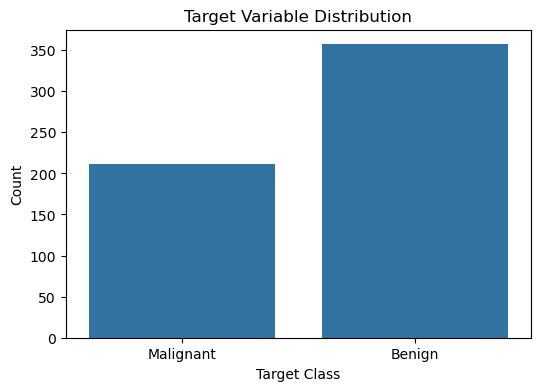

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Target Variable Distribution")
plt.xlabel("Target Class")
plt.ylabel("Count")
plt.xticks([0,1], ["Malignant", "Benign"])

plt.show()

### Observations

* **Benign (1): 357 samples**
* **Malignant (0): 212 samples**

The dataset is **slightly imbalanced**, with approximately **63% benign** and **37% malignant** observations.

### Engineering Interpretation

The imbalance is not severe, so standard classification algorithms can still be applied directly. However, relying solely on **accuracy** may be misleading because correctly identifying **malignant tumors** is more important than maximizing overall accuracy.

For this reason, **Precision, Recall, and F1-score** will also be evaluated during model assessment.


## 7. Train-Test Split

The dataset is divided into **training and testing sets**.

* **Training set:** used to learn patterns from the data.
* **Testing set:** used to evaluate the model on unseen observations.

An **80/20 split** is used, and **stratification** is applied to preserve the original class distribution in both subsets. A fixed `random_state` ensures reproducible results.


In [13]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.2,
    stratify=y
)

print("X_train:",X_train.shape)
print("X_test:",X_test.shape)
print("y_train:",y_train.shape)
print("y_test:",y_test.shape)


X_train: (455, 30)
X_test: (114, 30)
y_train: (455,)
y_test: (114,)


### Observations

* **Training Set:** 455 samples × 30 features
* **Testing Set:** 114 samples × 30 features

The split follows an **80/20 ratio**, providing sufficient data for model learning while preserving a separate unseen dataset for evaluation.

Because **stratification** was applied, both training and testing sets maintain approximately the same class distribution as the original dataset, reducing evaluation bias.


## 8. Feature Scaling

KNN is a **distance-based algorithm**, which means features with larger numerical values can dominate the distance calculation.

To ensure that all features contribute equally, the data is standardized using **StandardScaler**.

### Why Standardization?

* Mean becomes **0**
* Standard deviation becomes **1**

The scaler is **fitted only on the training data** and then applied to both training and testing datasets to prevent **data leakage**.


In [15]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

## 9. Baseline KNN Classifier

A baseline **K-Nearest Neighbors Classifier** is trained using **K = 5**.

The model predicts the class of a new observation by examining the **five nearest training samples** and assigning the majority class among those neighbors.

This baseline model provides a reference point that will later be improved through **hyperparameter tuning**.


In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Baseline KNN Accuracy:", accuracy)

Baseline KNN Accuracy: 0.956140350877193


## 10. Model Evaluation

The baseline KNN model is evaluated on the **unseen test dataset**.

The first metric used is **Accuracy**, which measures the proportion of correctly classified observations.

Although accuracy provides a useful initial estimate of model performance, additional metrics such as **Precision, Recall, and F1-score** are also required for a complete evaluation of a classification model.


In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Baseline KNN Accuracy:", accuracy)

Baseline KNN Accuracy: 0.956140350877193


### Observations

The baseline KNN classifier achieved **95.61% accuracy** on the test dataset.

This indicates that the model correctly classified the majority of unseen patient records.

### Engineering Interpretation

Accuracy provides a useful initial assessment of model performance. However, because this is a **medical diagnosis problem**, it is also necessary to evaluate **Precision, Recall, and F1-score**, particularly for the **malignant tumor class**, where prediction errors may have serious clinical consequences.


## 10.2 Confusion Matrix

A confusion matrix provides a detailed breakdown of **correct and incorrect predictions**.

It allows us to identify:

* correctly classified malignant tumors,
* correctly classified benign tumors,
* malignant tumors incorrectly predicted as benign,
* and benign tumors incorrectly predicted as malignant.

This is especially important in healthcare applications, where different types of prediction errors have different clinical consequences.


[[39  3]
 [ 2 70]]


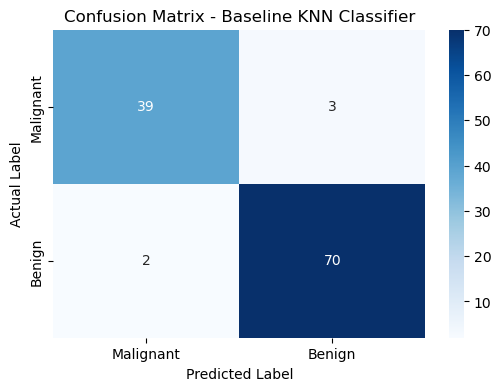

In [20]:
cm = confusion_matrix(y_test, y_pred)

print(cm)


plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix - Baseline KNN Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Interpretation

The confusion matrix shows that:

* **39 malignant tumors were correctly identified.**
* **70 benign tumors were correctly identified.**
* **3 malignant tumors were incorrectly classified as benign.**
* **2 benign tumors were incorrectly classified as malignant.**

### Engineering Interpretation

The model makes only **5 errors out of 114 test samples**, indicating strong classification performance.

The most important error is the **3 malignant tumors predicted as benign**, because failing to detect a cancer case can have serious clinical consequences.

This suggests that **Recall for the malignant class** should be carefully monitored during model evaluation.


In [21]:
print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 10.3 Classification Report

The classification report provides **Precision, Recall, F1-score, and Support** for each class.

* **Precision:** How many predicted positive cases are actually positive.
* **Recall:** How many actual positive cases are correctly identified.
* **F1-score:** Harmonic mean of Precision and Recall.
* **Support:** Number of actual samples belonging to each class.

These metrics provide a more complete evaluation than accuracy alone, especially in classification problems where different types of errors have different costs.


### Interpretation

The baseline KNN classifier achieved **95.6% accuracy** on the test dataset.

#### Malignant Class

* **Precision:** 0.95
* **Recall:** 0.93
* **F1-score:** 0.94

The model correctly identified **39 out of 42 malignant tumors**, missing **3 malignant cases**.

#### Benign Class

* **Precision:** 0.96
* **Recall:** 0.97
* **F1-score:** 0.97

The model correctly identified **70 out of 72 benign tumors**.

### Engineering Interpretation

The classifier performs strongly across both classes, with balanced precision and recall. However, because this is a **medical diagnosis problem**, the **3 missed malignant tumors** are clinically significant. Future improvements should focus on increasing **recall for the malignant class**, even if precision decreases slightly, because failing to detect cancer is typically more costly than performing additional diagnostic tests.


## 11. Hyperparameter Tuning with GridSearchCV

The baseline KNN model used **K = 5**, but this may not be the optimal number of neighbors.

To identify the best value of **K**, **GridSearchCV** is used.

GridSearchCV evaluates multiple values of `n_neighbors` using **cross-validation**, allowing the model to be selected based on average validation performance rather than a single train-test split.

This reduces the risk of selecting a hyperparameter that performs well only on one particular data split.


### 11.1 Import GridSearchCV

`GridSearchCV` is used to perform **systematic hyperparameter tuning** by evaluating multiple values of `n_neighbors` using cross-validation.


### 11.2 Define the Parameter Grid

A **parameter grid** specifies the hyperparameter values that GridSearchCV will evaluate.

For KNN, the primary hyperparameter is **`n_neighbors`**, so values from **1 to 30** are tested.

Because the model is inside a **Pipeline**, the parameter is referenced as **`knn__n_neighbors`** (`step_name__parameter_name`).


In [23]:
param_grid = {
    "knn__n_neighbors": list(range(1, 31))
}

print(param_grid)

{'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]}


In [24]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

### 11.3 Configure GridSearchCV

GridSearchCV is configured to tune the **number of neighbors (`n_neighbors`)** using **5-fold cross-validation**.

The optimization metric is **Recall**, because in medical diagnosis problems it is more important to correctly identify **malignant tumors** than to maximize overall accuracy.


The pipeline is used as the estimator so that **feature scaling is performed automatically within each cross-validation fold**, preventing data leakage.


In [25]:
grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

### 11.4 Train GridSearchCV

The grid search is trained using the **training dataset**.

For each candidate value of `n_neighbors`, the pipeline is evaluated using **5-fold cross-validation**, and the average **Recall** score is computed.

The value of **K** that produces the highest average recall is selected automatically.


In [27]:
grid_search.fit(X_train,y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29, 30]},
             scoring='recall')

### 11.5 Best Hyperparameters

After evaluating all candidate values of **`n_neighbors`**, GridSearchCV returns:

* the **best hyperparameter combination**, and
* the **best average cross-validation recall**.

This represents the configuration that performed best during the tuning process on the training data.


In [30]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Recall:", grid_search.best_score_)

Best Parameters: {'knn__n_neighbors': 9}
Best Cross-Validation Recall: 0.9894736842105264


### Interpretation

GridSearchCV identified **`n_neighbors = 9`** as the optimal value based on **Recall**.

The model achieved an average cross-validation recall of **98.95%**, indicating that it was able to correctly identify nearly all positive cases across the validation folds.

### Engineering Interpretation

Using **9 neighbors** produced a more stable neighborhood structure than the baseline configuration (`K = 5`), reducing sensitivity to noisy observations while maintaining excellent detection performance.

The test dataset has not yet been used, ensuring that the final evaluation remains **unbiased**.


## 12. Evaluate the Tuned KNN Model

The **best pipeline selected by GridSearchCV** is used to generate predictions on the **unseen test dataset**.

Because the pipeline contains both **StandardScaler** and **KNeighborsClassifier**, preprocessing is applied automatically before prediction.


In [35]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

### 12.1 Accuracy of the Tuned Model

The tuned KNN model selected by GridSearchCV is evaluated on the **unseen test dataset**.

This accuracy is compared with the baseline model to determine whether hyperparameter tuning improved generalization performance.


In [36]:
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("Tuned KNN Accuracy:", accuracy_tuned)

Tuned KNN Accuracy: 0.9736842105263158


### Comparison with Baseline Model

| Model        |  K |   Accuracy |
| ------------ | -: | ---------: |
| Baseline KNN |  5 | **95.61%** |
| Tuned KNN    |  9 | **97.37%** |

### Engineering Interpretation

Hyperparameter tuning improved the model accuracy by **1.76 percentage points**.

The tuned model with **K = 9** demonstrates better generalization performance than the baseline configuration and will be used for the final evaluation.


[[39  3]
 [ 0 72]]


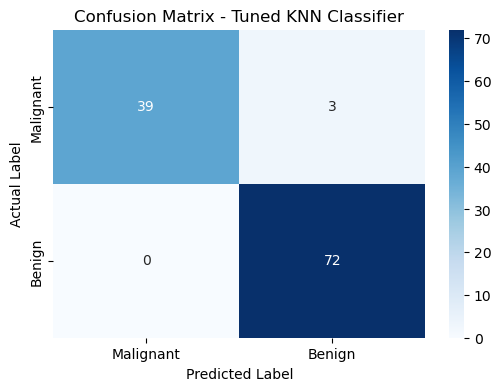

In [37]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print(cm_tuned)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Malignant", "Benign"],
    yticklabels=["Malignant", "Benign"]
)

plt.title("Confusion Matrix - Tuned KNN Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Comparison with Baseline Confusion Matrix

| Metric                        | Baseline (K=5) | Tuned (K=9) |
| ----------------------------- | -------------: | ----------: |
| Correct Malignant Predictions |             39 |          39 |
| Missed Malignant Tumors       |              3 |           3 |
| Benign Predicted as Malignant |              2 |           0 |
| Correct Benign Predictions    |             70 |          72 |

### Engineering Interpretation

The tuned model improved overall accuracy from **95.61% to 97.37%** by eliminating **false positive predictions on benign patients**.

The model still misses **3 malignant tumors**, indicating that recall for the malignant class did not improve on the test dataset.

Therefore, the tuned model is **more precise** while maintaining the same malignant detection performance as the baseline model.


### 12.3 Classification Report of the Tuned Model

The tuned KNN classifier is evaluated using **Precision, Recall, F1-score, and Support**.

These metrics are compared with the baseline model to determine which aspects of performance improved after hyperparameter tuning.


In [38]:
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Malignant", "Benign"]
))

              precision    recall  f1-score   support

   Malignant       1.00      0.93      0.96        42
      Benign       0.96      1.00      0.98        72

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



## 13. Final Model Comparison

| Metric              | Baseline (K=5) | Tuned (K=9) |
| ------------------- | -------------: | ----------: |
| Accuracy            |         95.61% |  **97.37%** |
| Malignant Precision |           0.95 |    **1.00** |
| Malignant Recall    |           0.93 |        0.93 |
| Malignant F1-score  |           0.94 |    **0.96** |
| Benign Precision    |           0.96 |        0.96 |
| Benign Recall       |           0.97 |    **1.00** |
| Benign F1-score     |           0.97 |    **0.98** |

### Engineering Interpretation

Hyperparameter tuning increased overall accuracy from **95.61% to 97.37%**.

The tuned model achieved **perfect malignant precision (1.00)**, meaning every patient predicted as malignant was actually malignant.

It also achieved **perfect benign recall (1.00)**, correctly identifying every benign patient in the test dataset.

However, malignant recall remained **0.93**, indicating that **3 malignant tumors were still missed**.

### Business Decision

For a clinical decision-support system, the tuned model with **K = 9** is preferred because it reduces unnecessary cancer diagnoses while maintaining the same malignant detection performance as the baseline model.
